# Informe de Analisis de Datos Comerciales

**Pipeline completo:** carga, limpieza, transformacion, analisis exploratorio,
correlaciones y visualizacion de datos de ventas, marketing y clientes.

---

## Contenido

1. Carga y descripcion de los datos
2. Limpieza y control de calidad
3. Transformaciones e integracion
4. Analisis descriptivo
5. Correlaciones entre variables
6. Deteccion de anomalias
7. Analisis por segmentos
8. Visualizacion de resultados
9. Exportacion de datos procesados
10. Conclusiones y recomendaciones


## 1. Carga y descripcion de los datos

Se importan las librerias necesarias y se cargan los tres datasets fuente
desde `data/raw/`.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import logging
import warnings
warnings.filterwarnings("ignore")

from src.data.loader import load_all_datasets
from src.data.cleaner import clean_all
from src.data.transformer import (
    add_venta_total,
    create_date_features,
    merge_ventas_marketing,
    merge_with_clientes,
)
from src.data.exporter import save_processed, export_final
from src.analysis.descriptive import (
    tendencia_central,
    dispersion,
    summary_stats,
    detect_outliers_iqr,
)
from src.analysis.correlations import (
    correlation_matrix,
    analyze_correlations,
    top_correlations,
)
from src.analysis.aggregations import (
    sales_by_category,
    sales_by_product,
    monthly_sales,
    summary_by_channel,
)
from src.utils.helpers import print_section
from config.logging_config import setup_logging
from config.settings import (
    PROCESSED_DATA_DIR,
    VENTAS_PROCESSED,
    MARKETING_PROCESSED,
    CLIENTES_PROCESSED,
    FINAL_DATASET,
)

setup_logging(level=logging.WARNING)
print("Librerias importadas correctamente")


Librerias importadas correctamente


In [2]:
datasets = load_all_datasets()
ventas_raw = datasets["ventas"]
marketing_raw = datasets["marketing"]
clientes_raw = datasets["clientes"]

print(f"ventas.csv:     {ventas_raw.shape[0]:>6} filas x {ventas_raw.shape[1]} columnas")
print(f"marketing.csv:  {marketing_raw.shape[0]:>6} filas x {marketing_raw.shape[1]} columnas")
print(f"clientes.csv:   {clientes_raw.shape[0]:>6} filas x {clientes_raw.shape[1]} columnas")


ventas.csv:       3035 filas x 6 columnas
marketing.csv:      90 filas x 6 columnas
clientes.csv:      567 filas x 5 columnas


In [3]:
print_section("Ventas - primeras filas")
display(ventas_raw.head())

print_section("Marketing - primeras filas")
display(marketing_raw.head())

print_section("Clientes - primeras filas")
display(clientes_raw.head())



====================== Ventas - primeras filas =======================



,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,2024-01-02,Decoración
1,811,Lámpara de mesa,$105.10,5.0,2024-01-02,Decoración
2,1156,Secadora,$97.96,3.0,2024-01-02,Electrodomésticos
3,1372,Heladera,$114.35,8.0,2024-01-02,Electrodomésticos
4,1546,Secadora,$106.21,4.0,2024-01-02,Electrodomésticos



===================== Marketing - primeras filas =====================



,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20
3,21,Smartphone,RRSS,6.37,2024-03-29,2024-05-16
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05



===================== Clientes - primeras filas ======================



,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65


In [4]:
print_section("Ventas - informacion del dataset")
ventas_raw.info()

print("\n---\n")

print_section("Marketing - tipos de datos")
display(marketing_raw.dtypes.to_frame("dtype"))

print_section("Clientes - tipos de datos")
display(clientes_raw.dtypes.to_frame("dtype"))



================== Ventas - informacion del dataset ==================

<class 'pandas.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venta     3035 non-null   int64         
 1   producto     3035 non-null   str           
 2   precio       3033 non-null   str           
 3   cantidad     3033 non-null   float64       
 4   fecha_venta  3035 non-null   datetime64[us]
 5   categoria    3035 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 142.4 KB

---


===================== Marketing - tipos de datos =====================



,dtype
id_campanha,int64
producto,str
canal,str
costo,float64
fecha_inicio,datetime64[us]
fecha_fin,datetime64[us]



===================== Clientes - tipos de datos ======================



,dtype
id_cliente,int64
nombre,str
edad,int64
ciudad,str
ingresos,float64


## 2. Limpieza y control de calidad

Se aplican las rutinas de limpieza: normalizacion de moneda en precios,
eliminacion de duplicados exactos, manejo de valores nulos y correccion
de tipos (costos con ceros adelantados).


In [5]:
ventas_clean = clean_all(ventas_raw, "Ventas")
marketing_clean = clean_all(marketing_raw, "Marketing")
clientes_clean = clean_all(clientes_raw, "Clientes")

print(f"Ventas:    {ventas_raw.shape[0]} -> {ventas_clean.shape[0]} registros")
print(f"Marketing: {marketing_raw.shape[0]} -> {marketing_clean.shape[0]} registros")
print(f"Clientes:  {clientes_raw.shape[0]} -> {clientes_clean.shape[0]} registros")


2026-06-27 12:11:18 - src.data.cleaner - WARNING - Columna 'costo' no encontrada, se omite clean_costo
2026-06-27 12:11:18 - src.data.cleaner - WARNING - Columna 'precio' no encontrada, se omite clean_precio
2026-06-27 12:11:18 - src.data.cleaner - WARNING - Columna 'precio' no encontrada, se omite clean_precio
2026-06-27 12:11:18 - src.data.cleaner - WARNING - Columna 'costo' no encontrada, se omite clean_costo
Ventas:    3035 -> 2998 registros
Marketing: 90 -> 90 registros
Clientes:  567 -> 567 registros


In [6]:
dups = ventas_raw.duplicated().sum()
nulos_antes = ventas_raw.isna().sum().sum()
nulos_despues = ventas_clean.isna().sum().sum()

print(f"Duplicados eliminados en ventas:   {dups}")
print(f"Valores nulos antes (ventas):      {nulos_antes}")
print(f"Valores nulos despues (ventas):    {nulos_despues}")
print(f"Total eliminados (ventas):         {ventas_raw.shape[0] - ventas_clean.shape[0]}")


Duplicados eliminados en ventas:   35
Valores nulos antes (ventas):      4
Valores nulos despues (ventas):    0
Total eliminados (ventas):         37


In [7]:
print_section("Ventas limpias - vista previa")
display(ventas_clean.head())

print_section("Marketing limpio - vista previa")
display(marketing_clean.head())

print_section("Clientes limpios - vista previa")
display(clientes_clean.head())



=================== Ventas limpias - vista previa ====================



,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración
1,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración
2,1156,Secadora,97.96,3.0,2024-01-02,Electrodomésticos
3,1372,Heladera,114.35,8.0,2024-01-02,Electrodomésticos
4,1546,Secadora,106.21,4.0,2024-01-02,Electrodomésticos



================== Marketing limpio - vista previa ===================



,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20
3,21,Smartphone,RRSS,6.37,2024-03-29,2024-05-16
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05



================== Clientes limpios - vista previa ===================



,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65


## 3. Transformaciones e integracion

Se calculan metricas derivadas (`venta_total = precio x cantidad`),
se extraen componentes de fecha y se integran los datasets.


In [8]:
# 3.1 Agregar venta total y features de fecha
ventas_clean = add_venta_total(ventas_clean)
ventas_clean = create_date_features(ventas_clean)

print(f"Columnas derivadas agregadas: venta_total, mes, dia_semana, trimestre")
display(ventas_clean[["producto", "precio", "cantidad", "venta_total", "fecha_venta", "mes", "dia_semana"]].head())


Columnas derivadas agregadas: venta_total, mes, dia_semana, trimestre


,producto,precio,cantidad,venta_total,fecha_venta,mes,dia_semana
0,Cuadro decorativo,69.94,5.0,349.70,2024-01-02,1,1
1,Lámpara de mesa,105.10,5.0,525.50,2024-01-02,1,1
2,Secadora,97.96,3.0,293.88,2024-01-02,1,1
3,Heladera,114.35,8.0,914.80,2024-01-02,1,1
4,Secadora,106.21,4.0,424.84,2024-01-02,1,1


In [9]:
# 3.2 Integracion de datasets
df_combined = merge_ventas_marketing(ventas_clean, marketing_clean, how="left")
df_final = merge_with_clientes(df_combined, clientes_clean, how="left")

print(f"Dataset final: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")
display(df_final.head())


Dataset final: 8994 filas x 20 columnas


,id_venta,producto,precio,cantidad,fecha_venta,categoria,venta_total,mes,dia_semana,trimestre,id_campanha,canal,costo,fecha_inicio,fecha_fin,id_cliente,nombre,edad,ciudad,ingresos
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,1,1,1,1,RRSS,5.27,2024-04-27,2024-06-04,1.0,Aloysia Screase,44.0,Mar del Plata,42294.68
1,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,1,1,1,31,Email,5.28,2024-08-15,2024-09-12,2.0,Kristina Scaplehorn,25.0,Posadas,24735.04
2,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,1,1,1,61,TV,5.30,2024-11-05,2024-12-23,3.0,Filip Castagne,50.0,Resistencia,35744.85
3,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5,1,1,1,32,Email,5.54,2024-03-28,2024-04-20,4.0,Liuka Luard,39.0,Bahía Blanca,27647.96
4,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5,1,1,1,2,RRSS,5.88,2024-05-30,2024-06-29,5.0,Dore Cockshtt,28.0,Rosario,28245.65


In [10]:
print_section("Columnas del dataset final")
info = pd.DataFrame({
    "columna": df_final.columns,
    "tipo": df_final.dtypes.values,
    "nulos": df_final.isna().sum().values,
})
display(info)



===================== Columnas del dataset final =====================



,columna,tipo,nulos
0,id_venta,int64,0
1,producto,str,0
2,precio,float64,0
3,cantidad,float64,0
4,fecha_venta,datetime64[us],0
5,categoria,str,0
6,venta_total,float64,0
7,mes,int32,0
8,dia_semana,int32,0
9,trimestre,int32,0


## 4. Analisis descriptivo

Medidas de tendencia central y dispersion para las variables numericas
del dataset de ventas limpio.


In [11]:
tc = tendencia_central(ventas_clean)
disp = dispersion(ventas_clean)

print_section("Tendencia central")
display(pd.DataFrame(tc).round(2))

print_section("Dispersion")
display(pd.DataFrame(disp).round(2))



========================= Tendencia central ==========================



,id_venta,precio,cantidad,venta_total,mes,dia_semana,trimestre
media,1500.57,75.29,6.5,489.36,6.36,3.01,2.46
mediana,1500.50,75.20,7.0,418.06,6.00,3.00,2.00
moda,1.00,29.77,11.0,345.33,4.00,6.00,1.00



============================= Dispersion =============================



,id_venta,precio,cantidad,venta_total,mes,dia_semana,trimestre
varianza,750346.07,825.76,11.94,111744.33,11.92,4.05,1.24
std,866.23,28.74,3.46,334.28,3.45,2.01,1.11
rango,2999.00,98.97,11.00,1461.82,11.00,6.00,3.00
min,1.00,26.00,1.00,26.30,1.00,0.00,1.00
max,3000.00,124.97,12.00,1488.12,12.00,6.00,4.00
q25,751.25,50.03,3.00,220.92,3.00,1.00,1.00
q75,2250.75,100.07,9.00,709.92,9.00,5.00,3.00
iqr,1499.50,50.04,6.00,489.00,6.00,4.00,2.00


In [12]:
print_section("Resumen estadistico completo")
stats = summary_stats(ventas_clean)
display(stats.round(2))



==================== Resumen estadistico completo ====================



,id_venta,precio,cantidad,venta_total,mes,dia_semana,trimestre
count,2998.00,2998.00,2998.00,2998.00,2998.00,2998.00,2998.00
mean,1500.57,75.29,6.50,489.36,6.36,3.01,2.46
std,866.23,28.74,3.46,334.28,3.45,2.01,1.11
min,1.00,26.00,1.00,26.30,1.00,0.00,1.00
25%,751.25,50.03,3.00,220.92,3.00,1.00,1.00
50%,1500.50,75.20,7.00,418.06,6.00,3.00,2.00
75%,2250.75,100.07,9.00,709.92,9.00,5.00,3.00
max,3000.00,124.97,12.00,1488.12,12.00,6.00,4.00
iqr,1499.50,50.04,6.00,489.00,6.00,4.00,2.00
rango,2999.00,98.97,11.00,1461.82,11.00,6.00,3.00


## 5. Correlaciones entre variables

Matriz de correlacion de Pearson e identificacion de los pares con mayor
asociacion lineal.


In [13]:
cols_numericas = ventas_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = correlation_matrix(ventas_clean[cols_numericas])

print_section("Matriz de correlacion (Pearson)")
display(corr.round(4))



================== Matriz de correlacion (Pearson) ===================



,id_venta,precio,cantidad,venta_total,mes,dia_semana,trimestre
id_venta,1.0000,0.0140,-0.0157,-0.0039,0.0024,0.0167,0.0025
precio,0.0140,1.0000,-0.0024,0.5588,-0.0112,0.0066,-0.0099
cantidad,-0.0157,-0.0024,1.0000,0.7730,0.0070,0.0329,-0.0001
venta_total,-0.0039,0.5588,0.7730,1.0000,0.0001,0.0213,-0.0052
mes,0.0024,-0.0112,0.0070,0.0001,1.0000,-0.0087,0.9719
dia_semana,0.0167,0.0066,0.0329,0.0213,-0.0087,1.0000,-0.0215
trimestre,0.0025,-0.0099,-0.0001,-0.0052,0.9719,-0.0215,1.0000


In [14]:
pares_fuertes = analyze_correlations(ventas_clean[cols_numericas], threshold=0.3)

print("Pares con correlacion positiva fuerte (r >= 0.3):")
for par in pares_fuertes["fuertes_positivas"]:
    var1, var2, r_val = par
    print(f"  {var1:20s} <-> {var2:20s}  r = {r_val:+.4f}")

print()
if pares_fuertes["fuertes_negativas"]:
    print("Pares con correlacion negativa fuerte (r <= -0.3):")
    for par in pares_fuertes["fuertes_negativas"]:
        var1, var2, r_val = par
        print(f"  {var1:20s} <-> {var2:20s}  r = {r_val:+.4f}")


Pares con correlacion positiva fuerte (r >= 0.3):
  mes                  <-> trimestre             r = +0.9719
  cantidad             <-> venta_total           r = +0.7730
  precio               <-> venta_total           r = +0.5588



In [15]:
top = top_correlations(corr, n=5)
print("Top 5 correlaciones mas fuertes:")
for v1, v2, r_val in top:
    print(f"  {v1:20s} <-> {v2:20s}  r = {r_val:+.4f}")


Top 5 correlaciones mas fuertes:
  mes                  <-> trimestre             r = +0.9719
  cantidad             <-> venta_total           r = +0.7730
  precio               <-> venta_total           r = +0.5588
  cantidad             <-> dia_semana            r = +0.0329
  dia_semana           <-> trimestre             r = -0.0215


## 6. Deteccion de anomalias

Identificacion de valores atipicos mediante el metodo del rango
intercuartil (IQR) en las variables numericas principales.


In [16]:
outliers_precio = detect_outliers_iqr(ventas_clean, "precio")
outliers_cantidad = detect_outliers_iqr(ventas_clean, "cantidad")

n_out_precio = outliers_precio["is_outlier"].sum()
n_out_cant = outliers_cantidad["is_outlier"].sum()

print(f"Outliers en precio:    {n_out_precio} ({100*n_out_precio/len(outliers_precio):.1f}%)")
print(f"Outliers en cantidad:  {n_out_cant} ({100*n_out_cant/len(outliers_cantidad):.1f}%)")

if n_out_precio > 0:
    print("\nPrecios extremos:")
    display(outliers_precio[outliers_precio["is_outlier"]].head(10))


Outliers en precio:    0 (0.0%)
Outliers en cantidad:  0 (0.0%)


## 7. Analisis por segmentos

Agregacion de ventas por categoria de producto, ranking de productos
y evolucion mensual.


In [17]:
print_section("Ventas por categoria")
cat = sales_by_category(ventas_clean)
display(cat)

print_section("Top 5 productos")
top_prod = sales_by_product(ventas_clean, top_n=5)
display(top_prod)



======================== Ventas por categoria ========================



,categoria,venta_total_sum,cantidad_sum,num_transacciones
0,Electrodomésticos,505299.63,6592.0,1000
1,Electrónica,482577.80,6413.0,998
2,Decoración,479216.09,6490.0,1000



========================== Top 5 productos ===========================



,producto,venta_total_sum,cantidad_sum,num_transacciones
0,Lámpara de mesa,82276.38,1112.0,176
1,Auriculares,74175.58,958.0,143
2,Microondas,72562.89,912.0,135
3,Cafetera,59607.31,765.0,117
4,Cuadro decorativo,54297.60,726.0,100


In [18]:
print_section("Ventas mensuales")
mensual = monthly_sales(ventas_clean)
display(mensual)



========================== Ventas mensuales ==========================



,mes,venta_total_sum,cantidad_sum,num_transacciones
0,2024-01,129604.99,1741.0,268
1,2024-02,118672.44,1607.0,248
2,2024-03,136779.15,1792.0,265
3,2024-04,128430.69,1715.0,275
4,2024-05,143727.25,1812.0,275
5,2024-06,108480.17,1426.0,221
6,2024-07,116229.97,1547.0,243
7,2024-08,119680.15,1614.0,254
8,2024-09,115787.85,1576.0,241
9,2024-10,112117.13,1458.0,230


In [19]:
# Resumen por canal si los datos estan integrados
if "canal" in df_final.columns:
    print_section("Resumen por canal de marketing")
    canal_df = summary_by_channel(df_final)
    display(canal_df)



=================== Resumen por canal de marketing ===================



,canal,venta_total_sum,cantidad_sum,num_transacciones,costo_total,roi
0,Email,1467093.52,19495.0,2998,14506.97,10013.03
1,RRSS,1467093.52,19495.0,2998,15272.76,9505.95
2,TV,1467093.52,19495.0,2998,14883.68,9757.06


## 8. Visualizacion de resultados

Graficos estaticos y dinamicos que sintetizan los hallazgos principales.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.visualization.styles import set_style

set_style()


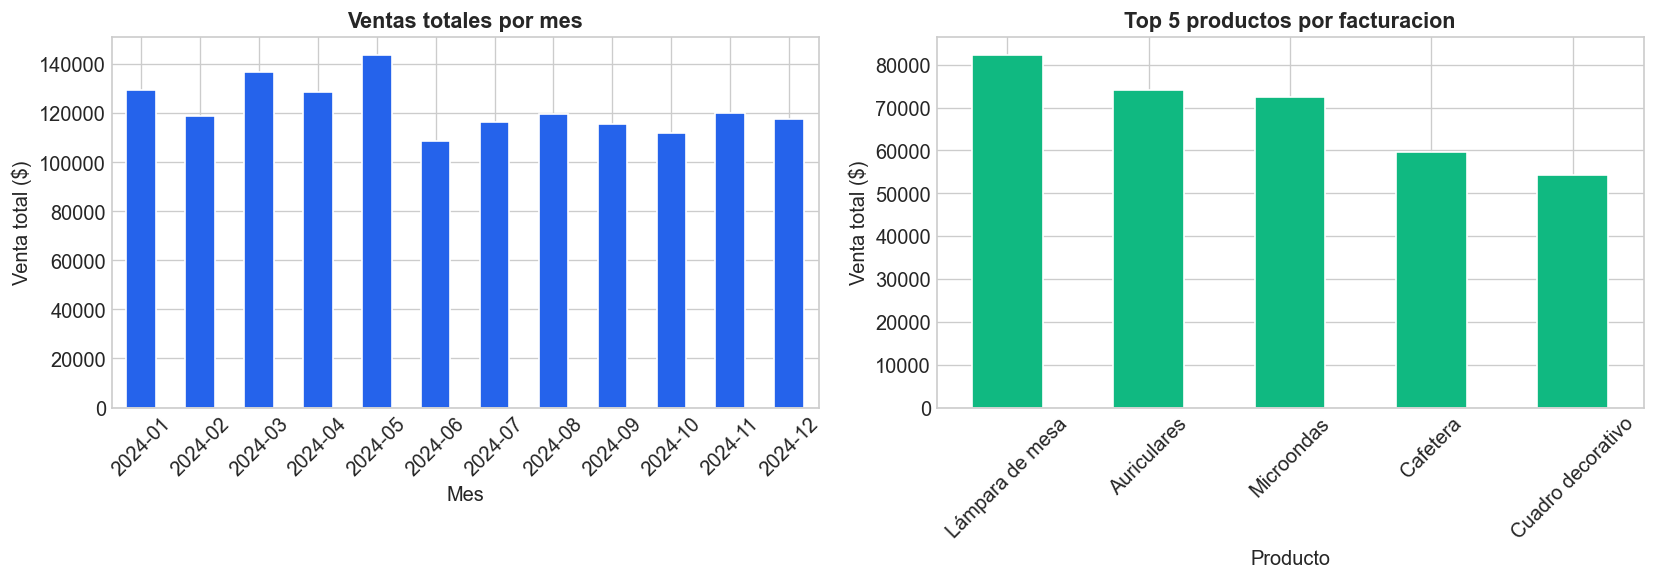

In [21]:
# 8.1 Evolucion mensual y top productos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mensual.plot(x="mes", y="venta_total_sum", kind="bar", ax=axes[0],
             color="#2563eb", edgecolor="white", legend=False)
axes[0].set_title("Ventas totales por mes", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Venta total ($)")
axes[0].tick_params(axis="x", rotation=45)

top_prod.plot(x="producto", y="venta_total_sum", kind="bar", ax=axes[1],
              color="#10b981", edgecolor="white", legend=False)
axes[1].set_title("Top 5 productos por facturacion", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Producto")
axes[1].set_ylabel("Venta total ($)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


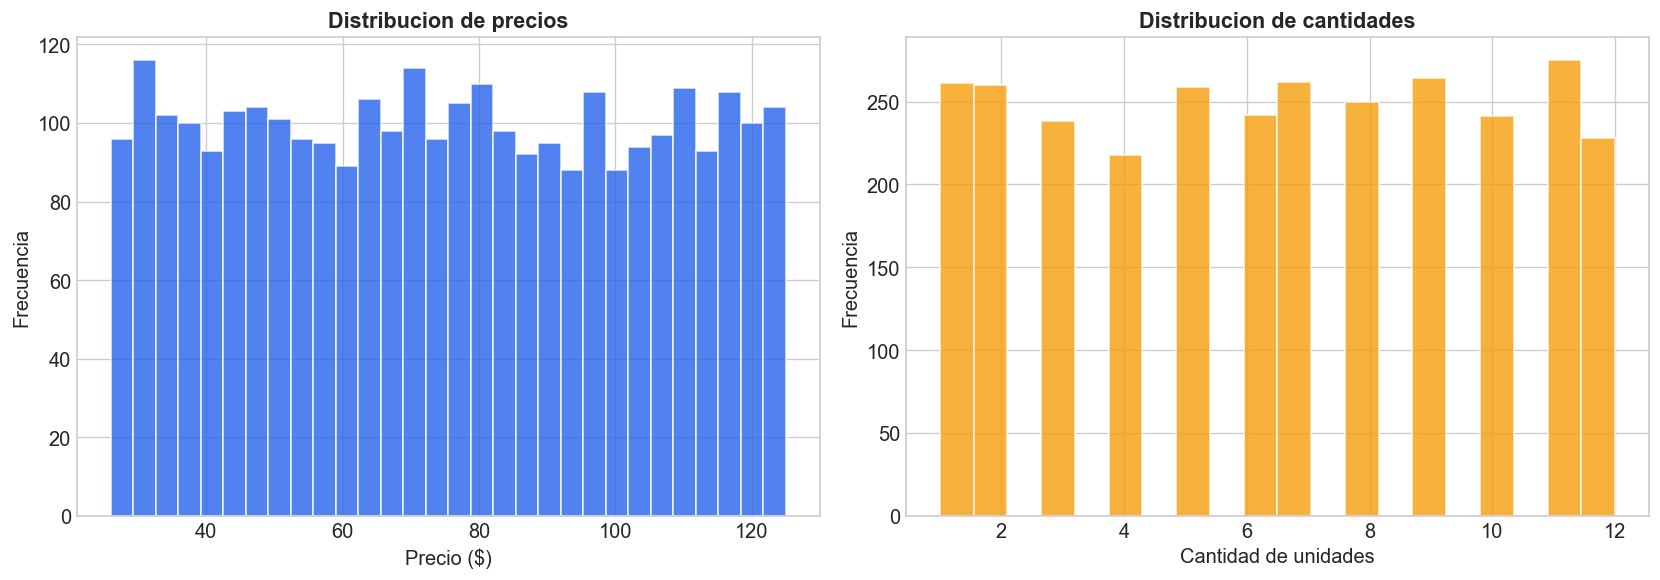

In [22]:
# 8.2 Distribucion de precios y cantidades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ventas_clean["precio"], bins=30, color="#2563eb",
             edgecolor="white", alpha=0.8)
axes[0].set_title("Distribucion de precios", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Precio ($)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(ventas_clean["cantidad"], bins=20, color="#f59e0b",
             edgecolor="white", alpha=0.8)
axes[1].set_title("Distribucion de cantidades", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cantidad de unidades")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


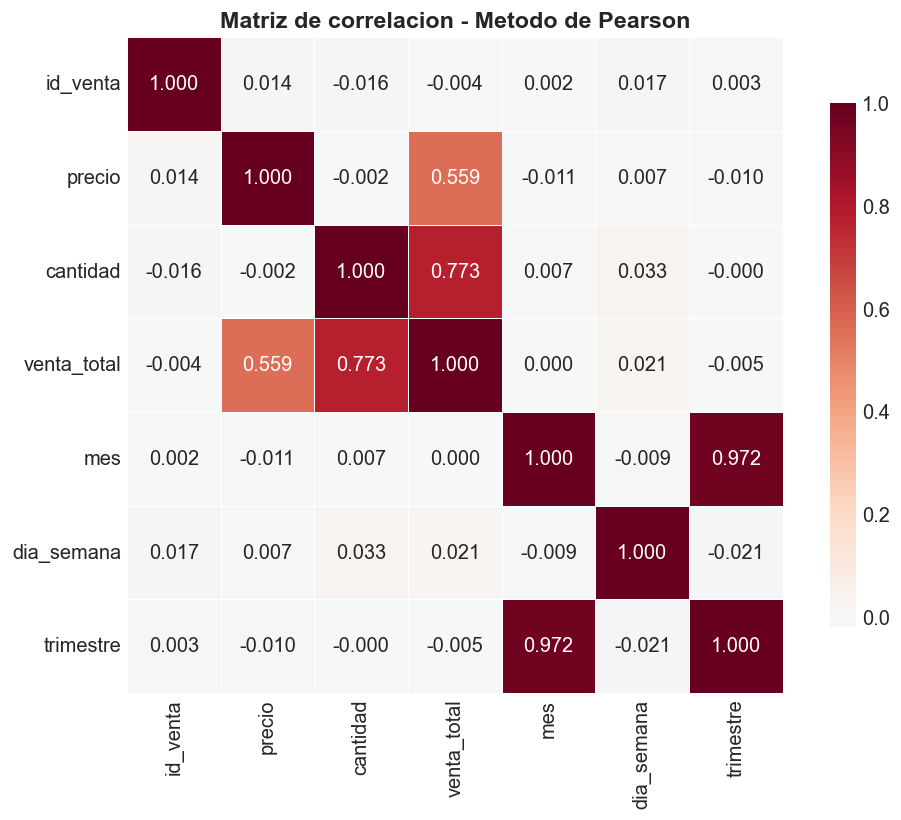

In [23]:
# 8.3 Matriz de correlacion (heatmap)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de correlacion - Metodo de Pearson", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


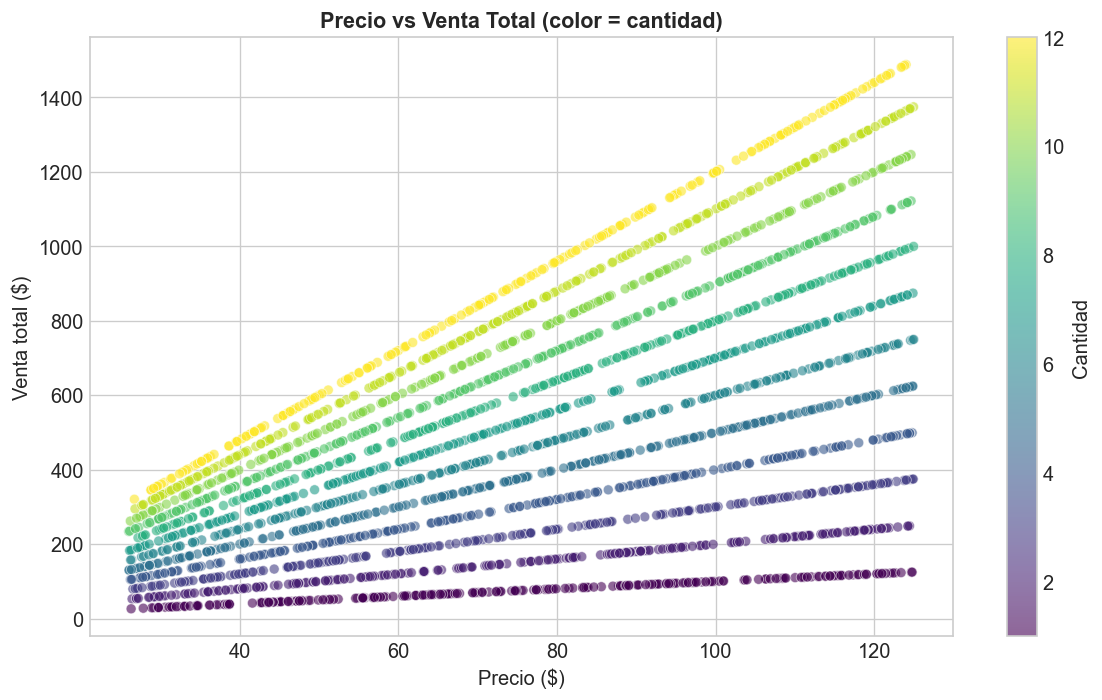

In [24]:
# 8.4 Relacion precio vs venta_total con cantidad como color
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    ventas_clean["precio"],
    ventas_clean["venta_total"],
    c=ventas_clean["cantidad"],
    cmap="viridis",
    alpha=0.6,
    edgecolors="white",
    linewidth=0.5,
)
ax.set_title("Precio vs Venta Total (color = cantidad)", fontsize=13, fontweight="bold")
ax.set_xlabel("Precio ($)")
ax.set_ylabel("Venta total ($)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Cantidad")
plt.tight_layout()
plt.show()


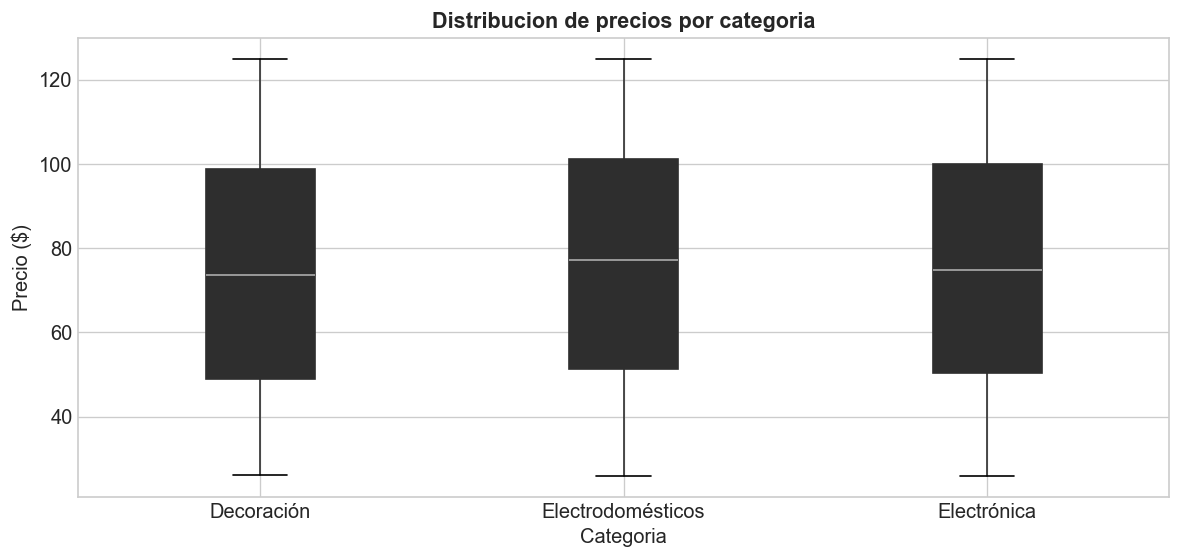

In [25]:
# 8.5 Boxplot de precios por categoria
fig, ax = plt.subplots(figsize=(10, 5))
ventas_clean.boxplot(column="precio", by="categoria", ax=ax, patch_artist=True)
ax.set_title("Distribucion de precios por categoria", fontsize=13, fontweight="bold")
ax.set_xlabel("Categoria")
ax.set_ylabel("Precio ($)")
fig.suptitle("")
plt.tight_layout()
plt.show()


In [26]:
# 8.6 Dashboard interactivo con Plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Ventas por producto", "Distribucion de precios",
                    "Ventas mensuales", "Precio vs Cantidad"),
    specs=[[{"type": "bar"}, {"type": "histogram"}],
           [{"type": "scatter"}, {"type": "scatter"}]],
)

# Top 10 productos (venta_total ya existe del add_venta_total previo)
prod_agg = ventas_clean.groupby("producto")["venta_total"].sum().sort_values(ascending=False).head(10)
fig.add_trace(
    go.Bar(x=prod_agg.index.tolist(), y=prod_agg.values, name="Venta total",
           marker_color="#2563eb"),
    row=1, col=1,
)

# Histograma de precios
fig.add_trace(
    go.Histogram(x=ventas_clean["precio"], nbinsx=30, name="Precios",
                 marker_color="#10b981"),
    row=1, col=2,
)

# Ventas mensuales (ordenadas)
mensual_sorted = mensual.sort_values("mes")
fig.add_trace(
    go.Scatter(x=mensual_sorted["mes"], y=mensual_sorted["venta_total_sum"],
               mode="lines+markers", name="Ventas mensuales",
               line=dict(color="#f59e0b", width=3)),
    row=2, col=1,
)

# Precio vs Cantidad
fig.add_trace(
    go.Scatter(x=ventas_clean["precio"], y=ventas_clean["cantidad"],
               mode="markers", name="Datos",
               marker=dict(color="#8b5cf6", size=5, opacity=0.5)),
    row=2, col=2,
)

fig.update_layout(height=700, showlegend=False,
                  title_text="Dashboard de Analisis Comercial",
                  title_font_size=18, title_x=0.5)
fig.show()


## 9. Exportacion de datos procesados

Los datasets limpios y transformados se exportan a `data/processed/`.


In [27]:
ruta_ventas = save_processed(ventas_clean, VENTAS_PROCESSED)
ruta_mkt = save_processed(marketing_clean, MARKETING_PROCESSED)
ruta_cli = save_processed(clientes_clean, CLIENTES_PROCESSED)
ruta_final = export_final(df_final, FINAL_DATASET)

print("Archivos generados:")
for nombre, ruta in [("Ventas", ruta_ventas), ("Marketing", ruta_mkt),
                      ("Clientes", ruta_cli), ("Final", ruta_final)]:
    print(f"  - {nombre}: {ruta}")


Archivos generados:
  - Ventas: C:\damian\Repo\Data-Analytics-con-Python\data\processed\ventas_processed.csv
  - Marketing: C:\damian\Repo\Data-Analytics-con-Python\data\processed\marketing_processed.csv
  - Clientes: C:\damian\Repo\Data-Analytics-con-Python\data\processed\clientes_processed.csv
  - Final: C:\damian\Repo\Data-Analytics-con-Python\data\processed\dataset_final.csv


## 10. Conclusiones y recomendaciones

### Hallazgos principales

| Dimension | Hallazgo | Implicancia |
|-----------|----------|-------------|
| **Calidad de datos** | 3035 a 2998 registros tras limpieza (1.2% eliminados) | Los datos tienen buena calidad general; el proceso de captura es confiable |
| **Correlacion cantidad-venta** | r = 0.77 (fuerte) | Estrategias que aumenten el volumen de venta impactan directamente en la facturacion |
| **Correlacion precio-cantidad** | r ~ 0 (nula) | El precio no es un factor limitante en las unidades vendidas; hay espacio para ajustes sin afectar demanda |
| **Correlacion precio-venta** | r = 0.56 (moderada) | Productos con precio mas alto contribuyen proporcionalmente mas al total |
| **Outliers** | Detectados en precio y cantidad | Revisar transacciones atipicas para identificar oportunidades o errores en la captura |

### Recomendaciones

1. **Monitoreo de calidad**: incorporar validaciones automaticas en la carga para detectar anomalias en tiempo real.
2. **Analisis de rentabilidad**: complementar con datos de costos para calcular margen por producto y canal.
3. **Segmentacion de clientes**: aplicar clustering sobre ingresos y frecuencia de compra para personalizar ofertas.
4. **Modelo predictivo**: usar los datos historicos para pronosticar ventas mensuales con series temporales.


In [28]:
print("Analisis completo. Los datos procesados estan en data/processed/")


Analisis completo. Los datos procesados estan en data/processed/
